# Predictive Analysis of Precipitation Trends in Toronto

This project applies the K-Nearest Neighbors regressor on precipitation data tracked across all of Toronto's wards to predict the precipitation levels in millimetres for the month of August. Precipitation data for Toronto is taken from the ["Rain Gauge Locations and Precipitation"](https://open.toronto.ca/dataset/rain-gauge-locations-and-precipitation/) dataset found on the municipal Open Data website. Toronto's wards are used to simplify and aggregate regions for rain tracking purposes.

To begin the project, the current precipitation data and the geospatial data on Toronto's wards need to be loaded. This requires the use of both Pandas and GeoPandas, as GeoPandas best represents and allows for the manipulation of geospatial data.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

data = pd.read_csv("precipitation-data-2026.csv")
data["date"] = pd.to_datetime(data["date"])

toronto = gpd.read_file("wards.geojson")

The below text was generated from the GeoJSON file, courtesy of Claude. I decided to use AI this way rather than sift through thousands of geospatial coordinates and characters to identify the geospatial boundaries for wards in the City of Toronto. Rest assured, the main coding was done by me.

In [32]:
ward_bounds = {
    'Humber River-Black Creek': [43.7129901010899, 43.7815790749568, -79.5852117269988, -79.4881735629245],
    'York Centre': [43.717755170299, 43.792407466692, -79.513221023395, -79.4114492180327],
    'Willowdale': [43.7492940526654, 43.8032701311798, -79.4466762521224, -79.38715209799],
    'University-Rosedale': [43.6493340834881, 43.6950870228904, -79.4293964137968, -79.3597108499133],
    'Beaches-East York': [43.6541630526509, 43.719785826787, -79.3330914324973, -79.2790326884178],
    'Scarborough Southwest': [43.6716713902779, 43.7431820122067, -79.3026450183565, -79.2127612905359],
    'Scarborough-Rouge Park': [43.7518781562957, 43.8554571861712, -79.2322978138953, -79.1154514950547],
    'Scarborough North': [43.7772824387948, 43.8420905838785, -79.2973325288169, -79.215721815678],
    'Scarborough-Guildwood': [43.7280935596794, 43.7965219057717, -79.2549798538438, -79.1792029490005],
    'Scarborough Centre': [43.7247131323866, 43.781222537134, -79.3197941465542, -79.2286728302396],
    'Scarborough-Agincourt': [43.7683633049312, 43.8259504741618, -79.3413178929128, -79.2747764602797],
    'Don Valley West': [43.6879167854284, 43.7663407333661, -79.408388704346, -79.3336886695626],
    "Toronto-St. Paul's": [43.670972707104, 43.711128749686, -79.4502789805454, -79.3848473659846],
    'Parkdale-High Park': [43.629793474517, 43.6673553150798, -79.5122116343354, -79.4254243849667],
    'Etobicoke North': [43.6685878284164, 43.7630179182296, -79.6392649324429, -79.5259742600834],
    'Etobicoke-Lakeshore': [43.5809960000775, 43.6628054218342, -79.5683543841088, -79.4691275896762],
    'Etobicoke Centre': [43.6254350948204, 43.7015979484891, -79.608734677802, -79.5054664261131],
    'Eglinton-Lawrence': [43.6921556119541, 43.7536163537944, -79.4725666844142, -79.3983665000037],
    'Don Valley North': [43.7633117314331, 43.8156507542373, -79.3962300578866, -79.3197941465542],
    'Don Valley East': [43.7030083763216, 43.7683633049312, -79.3629278029548, -79.3005925599442],
    'Davenport': [43.6406101768552, 43.6956920028916, -79.4705581756293, -79.4207821526692],
    'Toronto Centre': [43.6457838773097, 43.673147823563, -79.3888691173455, -79.3495236876076],
    'York South-Weston': [43.6626336614198, 43.7248699022048, -79.5395981412305, -79.4600458827451],
    'Toronto-Danforth': [43.6127319637984, 43.7033709024658, -79.3663684190196, -79.3131352772325],
    'Spadina-Fort York': [43.6119544056144, 43.6557159692698, -79.4287065660649, -79.3472969332]
}

In [33]:
def process_to_density(dataset):
    dataset = dataset.groupby('name').agg(
        total_rainfall=('rainfall', 'sum'),
        latitude = ('latitude', 'mean'),
        longitude = ('longitude', 'mean')
    )

    dataset = dataset.reset_index(names="name")
    dataset["ward"] = "N/A"

    for (idx, row) in enumerate(dataset.loc[:,["name", "latitude", "longitude"]].itertuples()):
        lat = row.latitude
        long = row.longitude
        for k, v in ward_bounds.items():
            if v[0] <= lat and lat <= v[1] and v[2] <= long and long <= v[3]:
                dataset.at[idx, "ward"] = k
                break

    dataset = dataset.groupby('ward').agg(
        rainfall = ('total_rainfall', 'max')
    )

    return dataset

In [34]:
january = data.query("date < '2026-02-01'")
january = process_to_density(january)

february = data.query("date >= '2026-02-01' and date < '2026-03-01'")
february = process_to_density(february)

march = data.query("date >= '2026-03-01' and date < '2026-04-01'")
march = process_to_density(march)

april = data.query("date >= '2026-04-01' and date < '2026-05-01'")
april = process_to_density(april)

may = data.query("date >= '2026-05-01' and date < '2026-06-01'")
may = process_to_density(may)

june = data.query("date >= '2026-06-01' and date < '2026-07-01'")
june = process_to_density(june)

july = data.query("date >= '2026-07-01' and date < '2026-08-01'")
july = process_to_density(july)

print("January data: \n ", january)
print("February data: \n ", february)
print("March data: \n ", march)
print("April data: \n ", april)
print("May data: \n ", may)
print("June data: \n ", june)
print("July data: \n ", july)

January data: 
                            rainfall
ward                              
Beaches-East York           83.105
Don Valley East             61.100
Don Valley North            69.222
Don Valley West             91.174
Eglinton-Lawrence          101.649
Etobicoke Centre            64.513
Etobicoke North             60.635
Etobicoke-Lakeshore         70.231
Humber River-Black Creek    66.487
Parkdale-High Park          61.592
Scarborough Centre          58.954
Scarborough North           59.383
Scarborough Southwest       71.150
Scarborough-Agincourt       75.464
Scarborough-Rouge Park     174.442
Spadina-Fort York           51.743
Toronto-St. Paul's          67.242
University-Rosedale        104.685
Willowdale                  56.895
York Centre                 85.017
York South-Weston           63.082
February data: 
                            rainfall
ward                              
Beaches-East York           51.820
Don Valley East             51.427
Don Valley North    

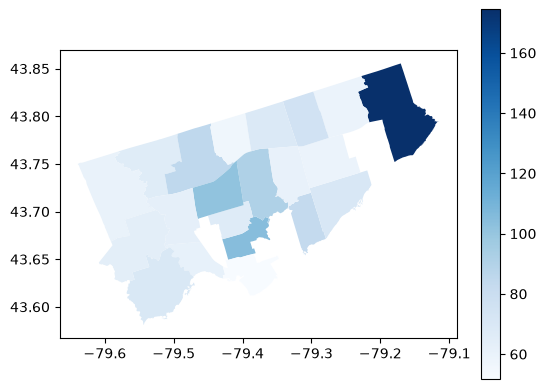

In [35]:
january_to = pd.merge(toronto, january, how="inner", left_on="AREA_NAME", right_index=True)
january_axis = january_to.plot("rainfall", legend=True, cmap="Blues")

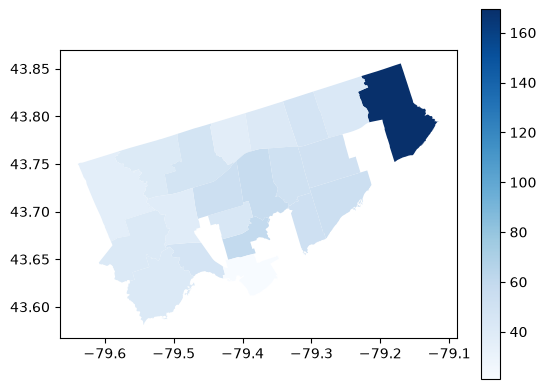

In [36]:
february_to = pd.merge(toronto, february, how="inner", left_on="AREA_NAME", right_index=True)
february_axis = february_to.plot("rainfall", legend=True, cmap="Blues")

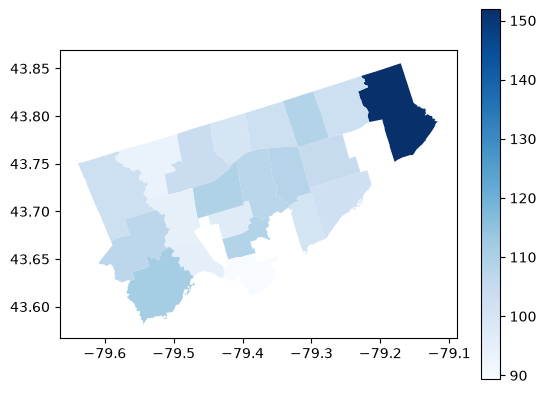

In [37]:
march_to = pd.merge(toronto, march, how="inner", left_on="AREA_NAME", right_index=True)
march_axis = march_to.plot("rainfall", legend=True, cmap="Blues")

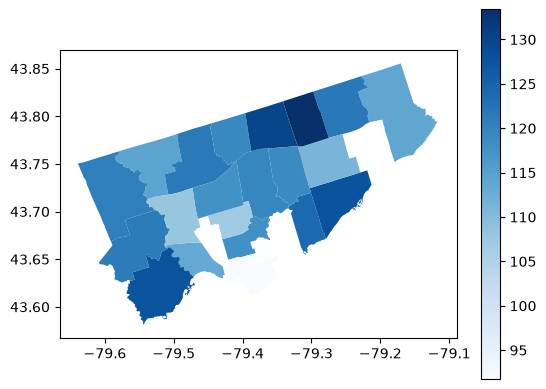

In [38]:
april_to = pd.merge(toronto, april, how="inner", left_on="AREA_NAME", right_index=True)
april_axis = april_to.plot("rainfall", legend=True, cmap="Blues")

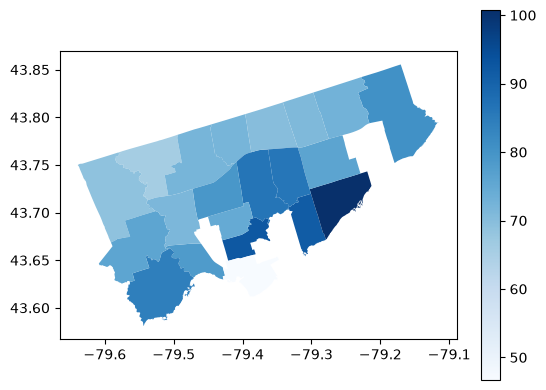

In [39]:
may_to = pd.merge(toronto, may, how="inner", left_on="AREA_NAME", right_index=True)
may_axis = may_to.plot("rainfall", legend=True, cmap="Blues")

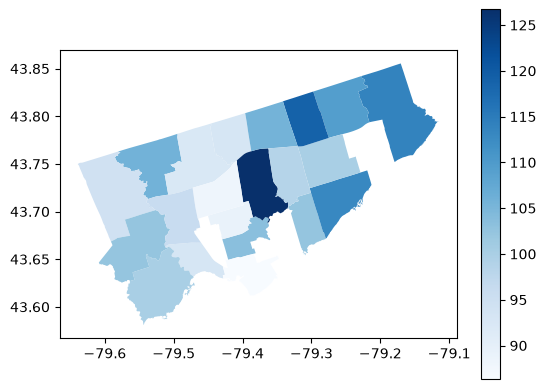

In [40]:
june_to = pd.merge(toronto, june, how="inner", left_on="AREA_NAME", right_index=True)
june_axis = june_to.plot("rainfall", legend=True, cmap="Blues")

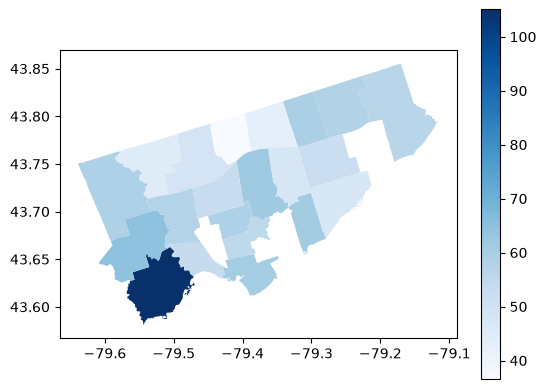

In [41]:
july_to = pd.merge(toronto, july, how="inner", left_on="AREA_NAME", right_index=True)
july_axis = july_to.plot("rainfall", legend=True, cmap="Blues")

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor 

monthly_data = pd.concat([january.rename(columns={"rainfall": "January"})
                          ,february.rename(columns={"rainfall": "February"})
                          ,march.rename(columns={"rainfall": "March"})
                          ,april.rename(columns={"rainfall": "April"})
                          ,may.rename(columns={"rainfall": "May"})
                          ,june.rename(columns={"rainfall": "June"})
                          ,july.rename(columns={"rainfall": "July"})
                          ], axis=1)

def predict(row):
    regressor = KNeighborsRegressor(weights='distance')
    regressor.fit(np.arange(stop=7).reshape(-1, 1), row)
    return regressor.predict(np.arange(stop=1).reshape(-1, 1))[0]

monthly_data["August (Prediction)"] =  monthly_data.apply(predict, axis=1)

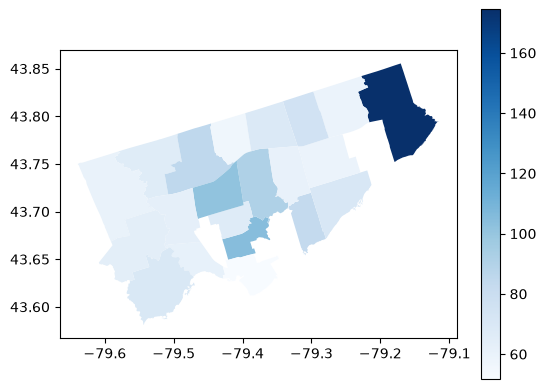

In [43]:
august_predicted_to = pd.merge(toronto, monthly_data["August (Prediction)"], how="inner", left_on="AREA_NAME", right_index=True)
august_predicted_axis = august_predicted_to.plot("August (Prediction)", legend=True, cmap="Blues")